# Thermal TCFs for Brownian double well

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
# random number generator seed: for later
seed = 31415
ss = np.random.SeedSequence(seed)
rng_seed_0, rng_seed_1 = ss.spawn(2)

 ## Contents

 1. [Units](#units)
 1. [PES](#potential-energy-surface)
 1. [System](#system)
 1. [Sampling propagator](#sampling-propagator)
 1. [Sampling run](#production-propagator)
 1. [Equilibration](#equilibration)
 1. [Production run](#production)

## Units

In [2]:
from rpmdgle.units import atomic
u = atomic()

## Potential energy surface

$$
V(x) = \frac{m \omega_b^2}{2} x^2 + \frac{m^2 \omega_b^4}{16 V_0} x^4 = \sum_{i = 0}^{4} c_i x_i^4
$$
with
$$
c_2 = \frac{m \omega_b^2}{2}, \quad c_4 = \frac{m^2 \omega_b^4}{16 V_0}
$$
and 0 otherwise.

In [3]:
from rpmdgle.pes.polynomial import PES as DWell
wb = u.wn2omega(500.0)
V0 = u.wn2energy(2085.0)
mass = 1837.36223469
coeffs = [
    0.0, 
    0.0, 
    -mass * wb**2/2,
    0.0,
    mass**2 * wb**4 / (16*V0)
]
PES = DWell(mass=mass, coeffs=coeffs, UNITS=u.__class__.__name__)
print(PES.x0)

0.0


## System

Set up the single-bead (classical) ring-polymer system

In [4]:
from rpmdgle.pes.pi import Ring
T = 300               # K, why not?
beta = u.betaTemp(T)
n_beads = 1
n_replicas = 100      # number of independent instances of the system
xshape = (1,)
rpPES = Ring(n_beads, xshape, PES, beta)
x = np.zeros((n_replicas, n_beads) + xshape)
p = np.zeros_like(x)


## Sampling propagator

This is the propagator used to sample the initial conditions from the thermal distribution: the Langevin dynamics is fictitious

In [5]:
from rpmdgle.propagators.langevin import RingPILE
tau = u.str2base("25 fs")
dt = u.str2base("0.5 fs")
sampling_propagator = RingPILE(
    rpPES, dt, x.shape, rng_seed_0, beta, tau)
sampling_propagator.set_x(x)
rng = sampling_propagator.rng
sampling_propagator.set_p(rng.normal(scale=np.sqrt(mass/beta), size=p.shape))

## Production propagator

This is used to propagate "literal" dissipative dynamics, $\tau$ is no longer chosen for efficiency of sampling. 

**Important** for comparison with i-PI, check if in the driver the friction tensor has dimensions [mass . time^(-1)] or [time^(-1)]; here, I assume the former

In [6]:
eta0 = 5.0
dt = u.str2base("0.5 fs")
production_propagator = RingPILE(
    rpPES, dt, x.shape, rng_seed_1, beta, (eta0/mass)**(-1))

## Equilibration

In [7]:
equilibration_time = u.str2base("10 ps") # let the system relaaaax
sampling_propagator.step(s = int(equilibration_time/sampling_propagator.dt))

## Production

In [8]:
from rpmdgle.utils.tcfs import time_averaged_correlation
relaxation_time = u.str2base("1 ps")
n_relaxation_steps = int(relaxation_time / sampling_propagator.dt)
trajectory_time = u.str2base("3 ps")
n_production_steps = int(trajectory_time / production_propagator.dt)
# how many sets of production trajectories to run?
n_samples = 10
# how often to record the positions and momenta?
stride = 2
# maximum lag time in the TCF:
t_lag = u.str2base("500 fs")
tcf_time_step = stride*production_propagator.dt
n_lag = int(t_lag/tcf_time_step)
cxx = np.zeros((n_lag+1, n_replicas))
cpp = np.zeros_like(cxx)
for _ in range(n_samples):
    # sample new phase-space coords from thermal distribution
    sampling_propagator.step(s = n_relaxation_steps)
    # resample momenta
    production_propagator.set_pnm(production_propagator.psample(beta))
    # copy positions from relaxation run
    production_propagator.set_xnm(sampling_propagator.xnm.copy())
    # phase-space coords at t=0
    positions = [ production_propagator.xnm[:,0,0].copy() ]
    momenta = [ production_propagator.pnm[:,0,0].copy() ]
    for _ in range(0, n_production_steps, stride):
        production_propagator.step(s=stride)
        # store new phase-space coords
        positions.append(production_propagator.xnm[:,0,0].copy())
        momenta.append(production_propagator.pnm[:,0,0].copy())
    # copy positions from the end of the production run
    sampling_propagator.set_xnm(production_propagator.xnm.copy())
    sampling_propagator.set_pnm(production_propagator.psample(beta))
    # update the TCFs
    positions = np.stack(positions, axis=0)
    cxx += time_averaged_correlation(positions, positions, n_lag, axis=0)
    momenta = np.stack(momenta, axis=0)
    cpp += time_averaged_correlation(momenta, momenta, n_lag, axis=0)
cxx /= n_samples
cxx_mean = cxx.mean(axis=-1)
cpp /= n_samples
cpp_mean = cpp.mean(axis=-1)


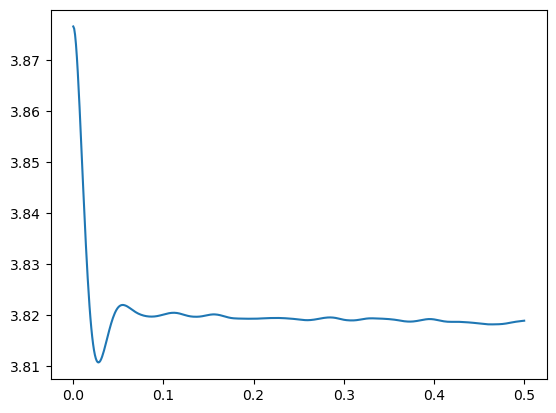

In [9]:
plt.plot(np.arange(n_lag+1)*tcf_time_step/u.str2base("1 ps"), cxx_mean)

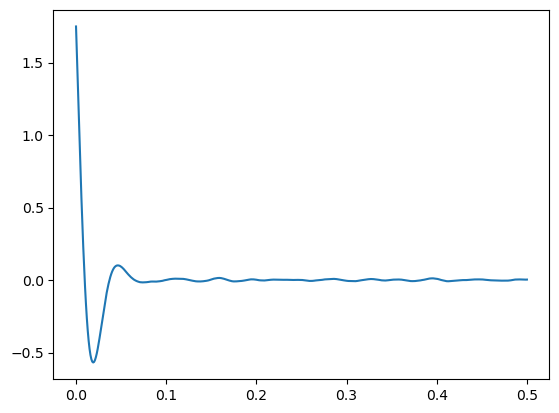

In [10]:
plt.plot(np.arange(n_lag+1)*tcf_time_step/u.str2base("1 ps"), cpp_mean)